# Unified Detection Analysis (Working + Potential Channels)

This notebook merges all current detector families into one calibration and fusion workflow.

Goals:
- Build one reproducible run manifest from structural benchmark outputs.
- Evaluate reliability for working and potential channels per model.
- Create a calibrated fusion detector with confidence and abstention.
- Run ablations to test generalization and channel usefulness.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import latest_structural_runs, select_run_files, load_json, get_model_name, iter_valid_tests, get_target_layer

In [ ]:
MODEL_FILTER = ['gpt2-large', 'gpt2-xl', 'qwen3-4b', 'qwen3-8b']
MAX_FILES = 500
USE_SWEEP_AWARE = True
SWEEP_ONLY = True

selection = 'latest_model_sweep' if USE_SWEEP_AWARE else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=MAX_FILES,
    model_substrings=MODEL_FILTER,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)

payload_pairs = [(p, load_json(p)) for p in run_files]
if SWEEP_ONLY:
    payload_pairs = [
        (p, payload)
        for p, payload in payload_pairs
        if str(payload.get('metadata', {}).get('sweep_slug') or 'single') != 'single'
    ]

run_files = [p for p, _ in payload_pairs]
payloads = [payload for _, payload in payload_pairs]

print(f'Loaded {len(payloads)} run files (selection={selection}, sweep_only={SWEEP_ONLY})')
for p in run_files:
    print(' -', p.name)

Loaded 12 sweep-style run files
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_14-23-43.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_14-07-42.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-57-39.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-47-38.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-42-54.json
 - rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-38-10.json
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-44-06.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-27-58.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-17-45.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-07-43.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02

In [3]:
def _get_nested(obj, path):
    cur = obj
    for key in path:
        if not isinstance(cur, dict):
            return None
        cur = cur.get(key)
    return cur

def _coerce_int(value):
    if value is None:
        return None
    try:
        return int(value)
    except (TypeError, ValueError):
        return None

def _coerce_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def _coerce_layer_map(value):
    out = {}
    if isinstance(value, dict):
        for k, v in value.items():
            try:
                lk = int(k)
            except (TypeError, ValueError):
                continue
            fv = _coerce_float(v)
            if np.isnan(fv):
                continue
            out[lk] = fv
        return out

    if isinstance(value, (list, tuple)):
        for i, v in enumerate(value):
            fv = _coerce_float(v)
            if np.isnan(fv):
                continue
            out[int(i)] = fv
        return out

    if isinstance(value, np.ndarray):
        if value.ndim == 1:
            for i, v in enumerate(value.tolist()):
                fv = _coerce_float(v)
                if np.isnan(fv):
                    continue
                out[int(i)] = fv
        return out

    return out

def _rank01_map(layer_map):
    if not layer_map:
        return {}
    layers = sorted(layer_map)
    vals = np.array([layer_map[l] for l in layers], dtype=float)
    vals = np.nan_to_num(vals, nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    order = np.argsort(vals)
    ranks = np.empty_like(vals, dtype=float)
    ranks[order] = np.arange(len(vals), dtype=float)
    ranks = ranks / max(1.0, float(len(vals) - 1))
    return {int(l): float(ranks[i]) for i, l in enumerate(layers)}

def _extract_prediction(block, pred_keys, score_keys):
    pred = None
    for key in pred_keys:
        if key in block:
            pred = _coerce_int(block.get(key))
            if pred is not None:
                break

    score = np.nan
    for key in score_keys:
        if key in block:
            score = _coerce_float(block.get(key))
            if not np.isnan(score):
                break

    return pred, score

def _extract_block(case, path):
    if not path:
        return {}
    block = _get_nested(case, path)
    if isinstance(block, dict):
        return block
    return {}

CHANNEL_SPECS = {
    'normal': {
        'block_path': ('normal_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['layer_z_score', 'detection_score', 'anomaly_score'],
        'series_paths': [('combined_score',), ('layer_anomaly_score',), ('layer_z_scores',), ('group_msd',), ('rank_one_score',)],
    },
    'composite': {
        'block_path': ('composite_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['composite_score', 'detection_score', 'anomaly_score'],
        'series_paths': [('combined_score',), ('layer_score_map',)],
    },
    'rank1_blind': {
        'block_path': ('rank1_blind_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['detection_score', 'anomaly_score'],
        'series_paths': [('combined_score',), ('contrast_series',), ('proj_series',), ('fc_series',), ('local_window_scores',)],
    },
    'spectral': {
        'block_path': ('spectral_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['anomaly_score', 'detection_score'],
        'series_paths': [('rome_hybrid_scores',), ('anomaly_score_array',), ('sv_z_scores',), ('sv_ratio_scores',), ('combined_score',)],
    },
    'ipr': {
        'block_path': ('ipr', 'detection'),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['anomaly_score', 'detection_score'],
        'series_paths': [('layer_scores',), ('combined_score',)],
    },
    'blind': {
        'block_path': ('blind_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['layer_anomaly_score', 'detection_score', 'anomaly_score'],
        'series_paths': [('isolation_scores',), ('layer_anomaly_score',), ('combined_score',)],
    },
    'attention': {
        'block_path': ('attention_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['detection_score', 'anomaly_score'],
        'series_paths': [('combined_score',), ('contrast_series',), ('local_window_scores',)],
    },
    'symmetry': {
        'block_path': ('symmetry_detection',),
        'pred_keys': ['anomalous_layer'],
        'score_keys': ['detection_score', 'anomaly_score'],
        'series_paths': [('combined_score',), ('mirror_top1_gap',), ('mirror_effective_rank_gap',), ('local_window_scores',)],
    },
}

def _extract_channel(case, channel, spec):
    block = _extract_block(case, spec.get('block_path', ()))
    if not block:
        return {'pred': None, 'score': np.nan, 'map': {}, 'has_block': False}

    pred, score = _extract_prediction(block, spec.get('pred_keys', []), spec.get('score_keys', []))

    chosen_map = {}
    for path in spec.get('series_paths', []):
        value = _get_nested(block, path)
        lm = _coerce_layer_map(value)
        if lm:
            chosen_map = lm
            break

    if not chosen_map:
        for _, value in block.items():
            lm = _coerce_layer_map(value)
            if len(lm) >= 3:
                chosen_map = lm
                break

    if pred is None and chosen_map:
        pred = int(max(chosen_map.items(), key=lambda kv: kv[1])[0])

    return {'pred': pred, 'score': score, 'map': _rank01_map(chosen_map), 'has_block': True}

In [4]:
pred_rows = []
map_rows = []

for run_path, payload in zip(run_files, payloads):
    run_file = run_path.name
    model = get_model_name(payload)

    for case in iter_valid_tests(payload):
        case_id = int(case.get('case_id', -1))
        target_layer = get_target_layer(payload, case)

        presence = case.get('edit_presence_detection', {}) if isinstance(case.get('edit_presence_detection'), dict) else {}
        is_edited = bool(presence.get('is_edited', True))
        presence_conf = _coerce_float(presence.get('confidence', presence.get('score', np.nan)))

        for channel, spec in CHANNEL_SPECS.items():
            item = _extract_channel(case, channel, spec)

            pred_rows.append({
                'model': model,
                'run_file': run_file,
                'case_id': case_id,
                'target_layer': target_layer if target_layer is not None else np.nan,
                'is_edited': is_edited,
                'presence_confidence': presence_conf,
                'channel': channel,
                'has_block': bool(item['has_block']),
                'has_pred': item['pred'] is not None,
                'pred_layer': item['pred'] if item['pred'] is not None else np.nan,
                'score': item['score'],
                'has_map': bool(item['map']),
            })

            for layer, val in item['map'].items():
                map_rows.append({
                    'model': model,
                    'run_file': run_file,
                    'case_id': case_id,
                    'target_layer': target_layer if target_layer is not None else np.nan,
                    'channel': channel,
                    'layer': int(layer),
                    'score_rank01': float(val),
                })

pred_df = pd.DataFrame(pred_rows)
map_df = pd.DataFrame(map_rows)

print('Prediction rows:', len(pred_df))
print('Layer-map rows:', len(map_df))
display(pred_df.head(20))

Prediction rows: 288
Layer-map rows: 9900


,model,run_file,case_id,target_layer,is_edited,presence_confidence,channel,has_block,has_pred,pred_layer,score,has_map
0,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,normal,True,True,12,5.916080e+00,True
1,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,composite,True,True,8,NaN,True
2,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,rank1_blind,True,True,12,8.946122e-01,True
3,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,spectral,True,True,21,1.565404e+00,True
4,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,ipr,True,True,4,5.587935e-08,False
5,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,blind,True,True,1,3.506249e+00,True
6,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,attention,True,True,13,7.952381e-01,True
7,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,True,0.934080,symmetry,True,True,2,9.000000e-01,True
8,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,1,12,True,0.953446,normal,True,True,12,5.916080e+00,True
9,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,1,12,True,0.953446,composite,True,True,12,NaN,True


In [5]:
eval_df = pred_df[pred_df['has_pred'] & pred_df['target_layer'].notna()].copy()

if eval_df.empty:
    raise RuntimeError('No valid predictions with target_layer found in selected runs.')

eval_df['abs_error'] = (eval_df['pred_layer'] - eval_df['target_layer']).abs()
eval_df['exact'] = eval_df['abs_error'] == 0
eval_df['hit_at_1'] = eval_df['abs_error'] <= 1
eval_df['hit_at_2'] = eval_df['abs_error'] <= 2
eval_df['hit_at_4'] = eval_df['abs_error'] <= 4

depth_map = {}
for model in sorted(pred_df['model'].unique()):
    vals = []
    vals.extend(pd.to_numeric(pred_df.loc[pred_df['model'] == model, 'target_layer'], errors='coerce').dropna().tolist())
    vals.extend(pd.to_numeric(pred_df.loc[pred_df['model'] == model, 'pred_layer'], errors='coerce').dropna().tolist())
    if not map_df.empty:
        vals.extend(pd.to_numeric(map_df.loc[map_df['model'] == model, 'layer'], errors='coerce').dropna().tolist())
    depth_map[model] = int(max(vals) + 1) if vals else 1

channel_metrics = (eval_df.groupby(['model', 'channel'])
                   .agg(
                       n=('exact', 'size'),
                       exact_accuracy=('exact', 'mean'),
                       hit_at_1=('hit_at_1', 'mean'),
                       hit_at_2=('hit_at_2', 'mean'),
                       hit_at_4=('hit_at_4', 'mean'),
                       mean_abs_error=('abs_error', 'mean'),
                       mean_score=('score', 'mean'),
                   )
                   .reset_index())

channel_metrics['depth'] = channel_metrics['model'].map(depth_map).astype(float)
channel_metrics['reliability'] = np.clip(1.0 - (channel_metrics['mean_abs_error'] / channel_metrics['depth']), 0.0, 1.0)

run_exact = (eval_df.groupby(['model', 'channel', 'run_file'])['exact']
             .mean()
             .reset_index(name='run_exact'))
run_stability = (run_exact.groupby(['model', 'channel'])['run_exact']
                 .std()
                 .fillna(0.0)
                 .reset_index(name='run_exact_std'))
run_stability['stability'] = 1.0 / (1.0 + (2.0 * run_stability['run_exact_std']))

channel_metrics = channel_metrics.merge(run_stability[['model', 'channel', 'stability']], on=['model', 'channel'], how='left')
channel_metrics['stability'] = channel_metrics['stability'].fillna(1.0)

BASE_WEIGHTS = {
    'normal': 0.40,
    'composite': 0.25,
    'rank1_blind': 0.20,
    'spectral': 0.10,
    'ipr': 0.05,
    'blind': 0.02,
    'attention': 0.02,
    'symmetry': 0.02,
}

channel_metrics['base_weight'] = channel_metrics['channel'].map(BASE_WEIGHTS).fillna(0.0)
channel_metrics['raw_weight'] = channel_metrics['base_weight'] * channel_metrics['reliability'] * channel_metrics['stability']

raw_sum = channel_metrics.groupby('model')['raw_weight'].transform('sum')
base_sum = channel_metrics.groupby('model')['base_weight'].transform('sum')
uniform_w = 1.0 / channel_metrics.groupby('model')['channel'].transform('count').clip(lower=1)

channel_metrics['calibrated_weight'] = np.where(
    raw_sum > 0.0,
    channel_metrics['raw_weight'] / raw_sum,
    np.where(base_sum > 0.0, channel_metrics['base_weight'] / base_sum, uniform_w),
)

display(channel_metrics.sort_values(['model', 'calibrated_weight'], ascending=[True, False]))

pivot_exact = channel_metrics.pivot(index='channel', columns='model', values='exact_accuracy')
pivot_mae = channel_metrics.pivot(index='channel', columns='model', values='mean_abs_error')
pivot_w = channel_metrics.pivot(index='channel', columns='model', values='calibrated_weight')

display(pivot_exact)
display(pivot_mae)
display(pivot_w)

,model,channel,n,exact_accuracy,hit_at_1,hit_at_2,hit_at_4,mean_abs_error,mean_score,depth,reliability,stability,base_weight,raw_weight,calibrated_weight
4,Qwen/Qwen3-4B,normal,12,1.000000,1.000000,1.000000,1.000000,0.000000,5.916080e+00,36.0,1.000000,1.000000,0.40,0.400000,0.520729
2,Qwen/Qwen3-4B,composite,12,0.500000,0.500000,0.500000,0.916667,2.416667,NaN,36.0,0.932870,0.537443,0.25,0.125341,0.163172
5,Qwen/Qwen3-4B,rank1_blind,12,0.833333,0.833333,0.833333,0.833333,1.666667,9.083350e-01,36.0,0.953704,0.600000,0.20,0.114444,0.148986
6,Qwen/Qwen3-4B,spectral,12,0.083333,0.083333,0.083333,0.083333,13.250000,1.424162e+00,36.0,0.631944,0.750000,0.10,0.047396,0.061701
3,Qwen/Qwen3-4B,ipr,12,0.000000,0.000000,0.000000,0.000000,9.000000,6.053597e-08,36.0,0.750000,1.000000,0.05,0.037500,0.048818
0,Qwen/Qwen3-4B,attention,12,0.000000,1.000000,1.000000,1.000000,1.000000,8.180952e-01,36.0,0.972222,1.000000,0.02,0.019444,0.025313
1,Qwen/Qwen3-4B,blind,12,0.000000,0.000000,0.000000,0.000000,11.000000,3.480464e+00,36.0,0.694444,1.000000,0.02,0.013889,0.018081
7,Qwen/Qwen3-4B,symmetry,12,0.000000,0.000000,0.000000,0.000000,17.750000,8.799762e-01,36.0,0.506944,1.000000,0.02,0.010139,0.013199
12,gpt2-large,normal,12,1.000000,1.000000,1.000000,1.000000,0.000000,5.916080e+00,36.0,1.000000,1.000000,0.40,0.400000,0.474357
13,gpt2-large,rank1_blind,12,0.000000,0.000000,0.000000,1.000000,3.000000,7.820000e-01,36.0,0.916667,1.000000,0.20,0.183333,0.217413


model,Qwen/Qwen3-4B,gpt2-large,gpt2-xl
channel,,,
attention,0.000000,0.000000,0.000000
blind,0.000000,0.000000,0.000000
composite,0.500000,0.333333,0.666667
ipr,0.000000,0.000000,0.000000
normal,1.000000,1.000000,1.000000
rank1_blind,0.833333,0.000000,0.000000
spectral,0.083333,0.333333,0.000000
symmetry,0.000000,0.000000,0.000000


model,Qwen/Qwen3-4B,gpt2-large,gpt2-xl
channel,,,
attention,1.000000,10.000000,18.000000
blind,11.000000,21.000000,17.000000
composite,2.416667,3.333333,8.333333
ipr,9.000000,3.000000,18.000000
normal,0.000000,0.000000,0.000000
rank1_blind,1.666667,3.000000,16.000000
spectral,13.250000,3.333333,6.833333
symmetry,17.750000,14.666667,20.000000


model,Qwen/Qwen3-4B,gpt2-large,gpt2-xl
channel,,,
attention,0.025313,0.017130,0.015544
blind,0.018081,0.009882,0.016062
composite,0.163172,0.152007,0.145163
ipr,0.048818,0.054353,0.038860
normal,0.520729,0.474357,0.497410
rank1_blind,0.148986,0.217413,0.165803
spectral,0.061701,0.060803,0.106650
symmetry,0.013199,0.014055,0.014508


In [6]:
map_lookup = {}
if not map_df.empty:
    for (model, run_file, case_id, channel), sub in map_df.groupby(['model', 'run_file', 'case_id', 'channel']):
        map_lookup[(model, run_file, int(case_id), channel)] = {
            int(l): float(v) for l, v in zip(sub['layer'].tolist(), sub['score_rank01'].tolist())
        }

pred_lookup = {}
for _, row in pred_df.iterrows():
    pred_lookup[(row['model'], row['run_file'], int(row['case_id']), row['channel'])] = row

model_layers = {m: np.arange(max(1, int(d)), dtype=int) for m, d in depth_map.items()}

SIGMA_BY_CHANNEL = {
    'normal': 1.0,
    'composite': 1.5,
    'rank1_blind': 1.5,
    'spectral': 2.0,
    'ipr': 2.0,
    'blind': 2.5,
    'attention': 2.5,
    'symmetry': 2.5,
}

VOTE_CHANNELS = ['normal', 'composite', 'rank1_blind', 'spectral', 'ipr', 'blind', 'attention', 'symmetry']

# Derived from ablation on current runs: prune channels that consistently hurt specific models.
MODEL_CHANNEL_EXCLUDE = {
    'gpt2-large': {'rank1_blind'},
    'gpt2-xl': {'symmetry'},
}

model_weight_lookup = {}
for model, sub in channel_metrics.groupby('model'):
    model_weight_lookup[model] = {
        r['channel']: float(r['calibrated_weight']) for _, r in sub.iterrows()
    }

def _build_curve(model, run_file, case_id, channel, layers):
    key = (model, run_file, int(case_id), channel)

    lm = map_lookup.get(key)
    if lm:
        vals = np.array([lm.get(int(l), np.nan) for l in layers], dtype=float)
        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        return vals, True

    row = pred_lookup.get(key)
    if row is None or not bool(row.get('has_pred', False)):
        return np.zeros(len(layers), dtype=float), False

    center = int(float(row['pred_layer']))
    sigma = float(SIGMA_BY_CHANNEL.get(channel, 2.0))
    raw_score = _coerce_float(row.get('score', np.nan))
    amp = 1.0 if np.isnan(raw_score) else max(0.0, raw_score)
    if amp == 0.0:
        amp = 1.0

    curve = amp * np.exp(-0.5 * ((layers - center) / max(1e-6, sigma)) ** 2)
    if np.max(curve) > np.min(curve):
        curve = (curve - np.min(curve)) / (np.max(curve) - np.min(curve))
    return curve, True

def _normalized_entropy(x):
    vals = np.array(x, dtype=float)
    vals = np.clip(vals, 0.0, None)
    if vals.sum() <= 0:
        return np.nan
    probs = vals / vals.sum()
    entropy = -np.sum(probs * np.log(np.clip(probs, 1e-12, 1.0)))
    return float(entropy / np.log(len(vals))) if len(vals) > 1 else 0.0

def run_fusion(vote_channels):
    case_rows = []

    case_view = (pred_df[['model', 'run_file', 'case_id', 'target_layer', 'is_edited', 'presence_confidence']]
                .drop_duplicates(subset=['model', 'run_file', 'case_id'])
                .copy())

    for _, c in case_view.iterrows():
        model = c['model']
        run_file = c['run_file']
        case_id = int(c['case_id'])
        target_layer = _coerce_int(c['target_layer'])
        is_edited = bool(c['is_edited'])
        presence_conf = _coerce_float(c['presence_confidence'])

        layers = model_layers.get(model, np.arange(1, dtype=int))

        if (not is_edited) and (not np.isnan(presence_conf)) and (presence_conf >= 0.5):
            case_rows.append({
                'model': model,
                'run_file': run_file,
                'case_id': case_id,
                'target_layer': target_layer if target_layer is not None else np.nan,
                'predicted_layer': np.nan,
                'confidence_margin': np.nan,
                'entropy': np.nan,
                'abstained': True,
                'channels_used': '',
                'reason': 'presence_gate_no_edit',
            })
            continue

        excluded = MODEL_CHANNEL_EXCLUDE.get(model, set())
        active_channels = [ch for ch in vote_channels if ch not in excluded]
        base_weights = model_weight_lookup.get(model, {})
        active = {ch: float(base_weights.get(ch, 0.0)) for ch in active_channels}
        denom = sum(active.values())
        if denom <= 0.0:
            active = {ch: 1.0 / max(1, len(active_channels)) for ch in active_channels}
        else:
            active = {ch: w / denom for ch, w in active.items()}

        fusion_score = np.zeros(len(layers), dtype=float)
        used_channels = []

        for channel, weight in active.items():
            curve, used = _build_curve(model, run_file, case_id, channel, layers)
            if not used:
                continue
            fusion_score = fusion_score + (weight * curve)
            used_channels.append(channel)

        if not used_channels:
            case_rows.append({
                'model': model,
                'run_file': run_file,
                'case_id': case_id,
                'target_layer': target_layer if target_layer is not None else np.nan,
                'predicted_layer': np.nan,
                'confidence_margin': np.nan,
                'entropy': np.nan,
                'abstained': True,
                'channels_used': '',
                'reason': 'no_channel_signal',
            })
            continue

        order = np.argsort(fusion_score)
        top_idx = int(order[-1])
        top_layer = int(layers[top_idx])
        top_val = float(fusion_score[top_idx])
        second_val = float(fusion_score[order[-2]]) if len(order) > 1 else float(top_val)
        margin = float(top_val - second_val)
        ent = _normalized_entropy(fusion_score)

        case_rows.append({
            'model': model,
            'run_file': run_file,
            'case_id': case_id,
            'target_layer': target_layer if target_layer is not None else np.nan,
            'predicted_layer': top_layer,
            'confidence_margin': margin,
            'entropy': ent,
            'abstained': False,
            'channels_used': ','.join(used_channels),
            'reason': 'ok',
        })

    out = pd.DataFrame(case_rows)

    valid_margin = out.loc[~out['abstained'] & out['confidence_margin'].notna(), ['model', 'confidence_margin']].copy()
    model_threshold = valid_margin.groupby('model')['confidence_margin'].quantile(0.25).to_dict() if not valid_margin.empty else {}

    out['margin_threshold'] = out['model'].map(model_threshold).fillna(0.0)
    out['abstained'] = out['abstained'] | (out['confidence_margin'] < out['margin_threshold'])
    return out

fusion_df = run_fusion(VOTE_CHANNELS)
display(fusion_df.head(30))

,model,run_file,case_id,target_layer,predicted_layer,confidence_margin,entropy,abstained,channels_used,reason,margin_threshold
0,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,12,0.155796,0.983810,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
1,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,1,12,12,0.156829,0.983841,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
2,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,2,12,12,0.155796,0.983827,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
3,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,0,12,12,0.053385,0.982668,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
4,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,1,12,12,0.053385,0.982658,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
5,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,2,12,12,0.050588,0.982616,True,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
6,gpt2-xl,rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_l...,0,18,18,0.042692,0.987668,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.008012
7,gpt2-xl,rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_l...,1,18,18,0.012843,0.987791,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.008012
8,gpt2-xl,rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_l...,2,18,18,0.111994,0.987377,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.008012
9,gpt2-xl,rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_l...,0,18,43,0.006451,0.982635,True,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.008012


In [7]:
def evaluate_predictions(df):
    if df.empty:
        return pd.DataFrame()

    eval_rows = df[(~df['abstained']) & df['target_layer'].notna() & df['predicted_layer'].notna()].copy()
    if eval_rows.empty:
        return pd.DataFrame()

    eval_rows['abs_error'] = (eval_rows['predicted_layer'] - eval_rows['target_layer']).abs()
    eval_rows['exact'] = eval_rows['abs_error'] == 0
    eval_rows['hit_at_1'] = eval_rows['abs_error'] <= 1
    eval_rows['hit_at_2'] = eval_rows['abs_error'] <= 2
    eval_rows['hit_at_4'] = eval_rows['abs_error'] <= 4

    summary = (eval_rows.groupby('model')
               .agg(
                   n=('exact', 'size'),
                   exact_accuracy=('exact', 'mean'),
                   hit_at_1=('hit_at_1', 'mean'),
                   hit_at_2=('hit_at_2', 'mean'),
                   hit_at_4=('hit_at_4', 'mean'),
                   mean_abs_error=('abs_error', 'mean'),
               )
               .reset_index())

    coverage = (df.groupby('model')['abstained'].mean().reset_index(name='abstain_rate'))
    summary = summary.merge(coverage, on='model', how='left')
    return summary.sort_values('model')

fusion_summary = evaluate_predictions(fusion_df)
display(fusion_summary)
display(fusion_df.sort_values(['model', 'run_file', 'case_id']).head(40))

,model,n,exact_accuracy,hit_at_1,hit_at_2,hit_at_4,mean_abs_error,abstain_rate
0,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333
1,gpt2-large,9,1.000000,1.000000,1.000000,1.000000,0.000000,0.250000
2,gpt2-xl,9,0.888889,0.888889,0.888889,0.888889,2.777778,0.250000


,model,run_file,case_id,target_layer,predicted_layer,confidence_margin,entropy,abstained,channels_used,reason,margin_threshold
21,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,0,12,12,0.053385,0.982658,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
22,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,1,12,12,0.053385,0.982655,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
23,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,2,12,12,0.053385,0.982583,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
3,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,0,12,12,0.053385,0.982668,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
4,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,1,12,12,0.053385,0.982658,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
5,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_...,2,12,12,0.050588,0.982616,True,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
18,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,3,12,12,0.087116,0.984753,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
19,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,4,12,12,0.170393,0.983838,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
20,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,5,12,12,0.078225,0.984699,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385
0,Qwen/Qwen3-4B,rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_...,0,12,12,0.155796,0.983810,False,"normal,composite,rank1_blind,spectral,ipr,blin...",ok,0.053385


In [8]:
ablation_rows = []
for dropped in ['none'] + VOTE_CHANNELS:
    if dropped == 'none':
        channels = list(VOTE_CHANNELS)
    else:
        channels = [c for c in VOTE_CHANNELS if c != dropped]

    out = run_fusion(channels)
    summary = evaluate_predictions(out)
    if summary.empty:
        continue
    summary['ablation'] = dropped
    ablation_rows.append(summary)

ablation_df = pd.concat(ablation_rows, ignore_index=True) if ablation_rows else pd.DataFrame()
display(ablation_df.sort_values(['model', 'ablation']))

,model,n,exact_accuracy,hit_at_1,hit_at_2,hit_at_4,mean_abs_error,abstain_rate,ablation
21,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,attention
18,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,blind
6,Qwen/Qwen3-4B,10,1.000000,1.000000,1.000000,1.000000,0.000000,0.166667,composite
15,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,ipr
0,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,none
3,Qwen/Qwen3-4B,9,0.222222,0.222222,0.222222,0.444444,10.888889,0.250000,normal
9,Qwen/Qwen3-4B,10,0.400000,0.400000,0.400000,0.400000,11.400000,0.166667,rank1_blind
12,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,spectral
24,Qwen/Qwen3-4B,11,1.000000,1.000000,1.000000,1.000000,0.000000,0.083333,symmetry
22,gpt2-large,9,1.000000,1.000000,1.000000,1.000000,0.000000,0.250000,attention


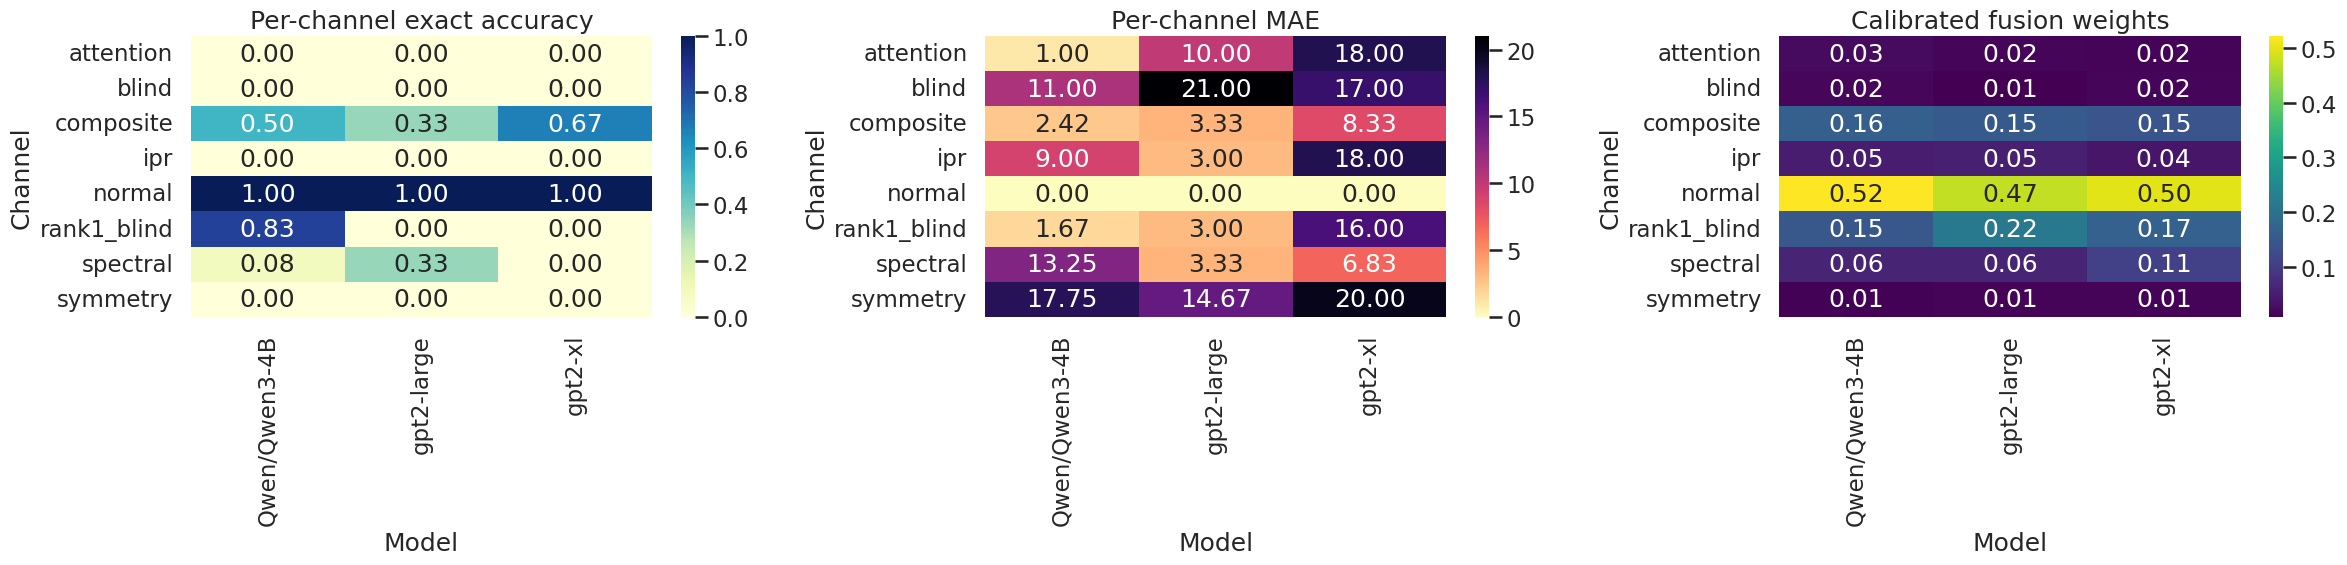

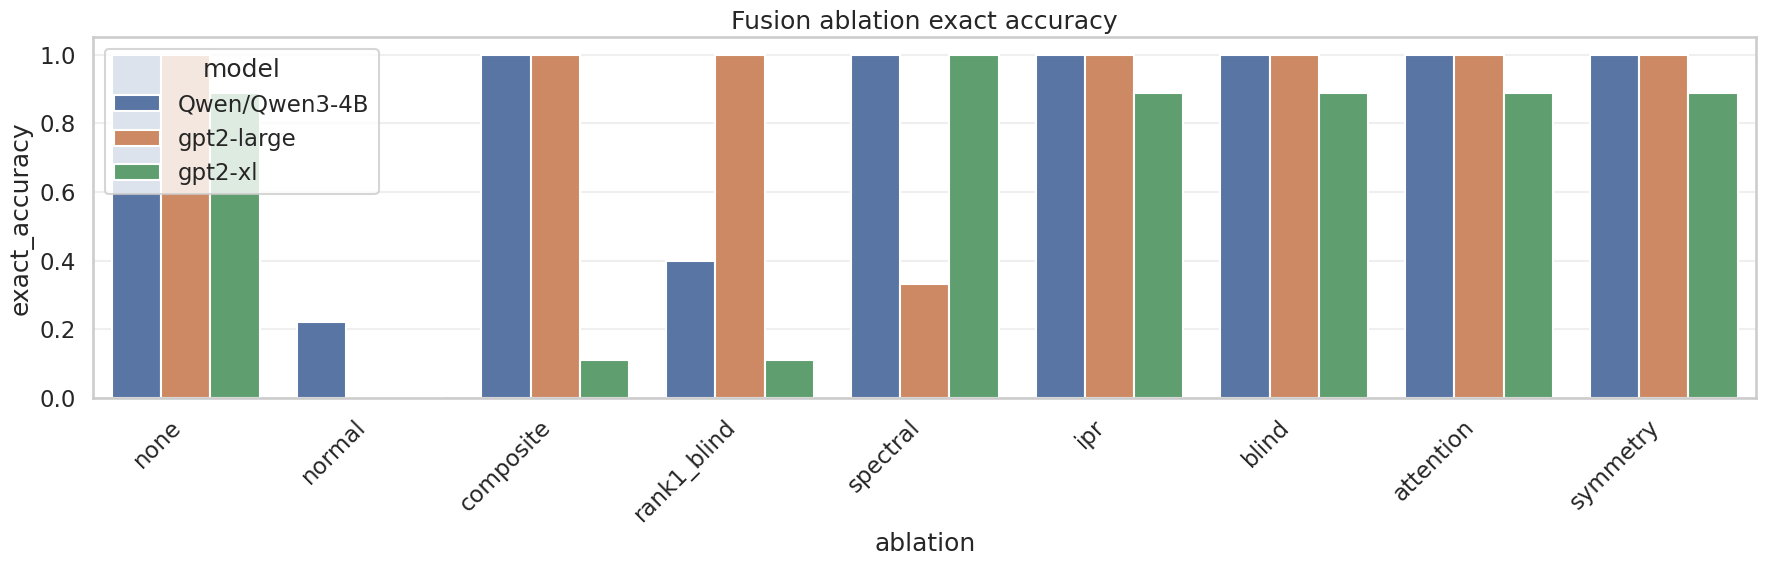

In [9]:
if not channel_metrics.empty:
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    sns.heatmap(channel_metrics.pivot(index='channel', columns='model', values='exact_accuracy'), annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
    axes[0].set_title('Per-channel exact accuracy')

    sns.heatmap(channel_metrics.pivot(index='channel', columns='model', values='mean_abs_error'), annot=True, fmt='.2f', cmap='magma_r', ax=axes[1])
    axes[1].set_title('Per-channel MAE')

    sns.heatmap(channel_metrics.pivot(index='channel', columns='model', values='calibrated_weight'), annot=True, fmt='.2f', cmap='viridis', ax=axes[2])
    axes[2].set_title('Calibrated fusion weights')

    for ax in axes:
        ax.set_xlabel('Model')
        ax.set_ylabel('Channel')
    plt.tight_layout()
    plt.show()

if not ablation_df.empty:
    plt.figure(figsize=(18, 6))
    sns.barplot(data=ablation_df, x='ablation', y='exact_accuracy', hue='model')
    plt.xticks(rotation=45, ha='right')
    plt.title('Fusion ablation exact accuracy')
    plt.tight_layout()
    plt.show()